In [1]:
import os
import glob
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
today = datetime.date.today()
date = today.strftime("%B%d")
date

'March05'

Load the tensorboard log files into pandas dataframe

In [3]:
# Gather data
data = []
logs = glob.glob(rf"..\logs\for_paper\wheeled_default_Aug09\*\*")
for log in logs:
    if "events.out.tfevents" in log:
        experiment_info = log.split('\\')[-2].split('_')
        algorithm = experiment_info[0]
        st = experiment_info[1]
        # print(log)
        print(log.split('\\'))
        print(experiment_info)
        
        for e in tf.compat.v1.train.summary_iterator(log):
            for v in e.summary.value:
                if v.tag == 'rollout/ep_rew_mean':
                    data.append({
                        'algorithm': algorithm,
                        'set': st,
                        'step': e.step,
                        'reward': v.simple_value
                    })
    else:
        print(f"Not a tensorflow log file, file: {log}")
df = pd.DataFrame(data)
os.makedirs("results", exist_ok=True)
df.to_csv(rf"results\wheeled_default_raw_{date}.csv")
df

['..', 'logs', 'for_paper', 'wheeled_default_Aug09', 'A2C_env1', 'events.out.tfevents.1754770697.gpu1.2113012.0']
['A2C', 'env1']

Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`
Not a tensorflow log file, file: ..\logs\for_paper\wheeled_default_Aug09\A2C_env1\log.txt
Not a tensorflow log file, file: ..\logs\for_paper\wheeled_default_Aug09\A2C_env1\progress.csv
Not a tensorflow log file, file: ..\logs\for_paper\wheeled_default_Aug09\A2C_env1\progress.json
['..', 'logs', 'for_paper', 'wheeled_default_Aug09', 'A2C_env2', 'events.out.tfevents.1754775034.gpu1.2113012.1']
['A2C', 'env2']
Not a tensorflow log file, file: ..\logs\for_paper\wheeled_default_Aug09\A2C_env2\log.txt
Not a tensorflow log file, file: ..\logs\for_paper\wheeled_default_Aug09\A2C_env2\progress.csv
Not a tensorflow log file, file: ..\logs\for_paper\wheeled_default_Aug09\A2C_env2\progress.json
['..', 'logs', 'for_paper', 'wheeled_default_Aug09', 'A2C_env3', 'events.out.tfevents.175478

,algorithm,set,step,reward
0,A2C,env1,2000,-98377.320312
1,A2C,env1,4000,-88210.289062
2,A2C,env1,6000,-89601.789062
3,A2C,env1,8000,-89147.164062
4,A2C,env1,10000,-89733.875000
...,...,...,...,...
34625,TRPO,env8,1974272,-46789.625000
34626,TRPO,env8,1982464,-46938.226562
34627,TRPO,env8,1990656,-47260.851562
34628,TRPO,env8,1998848,-47338.949219


In [4]:
df['algorithm'].unique()

array(['A2C', 'ARS', 'CrossQ', 'PPO', 'TQC', 'TRPO'], dtype=object)

In [5]:
# Scaling the rewards for visualization
df['reward_scaled'] = df['reward'] / 1000000
df['reward_scaled'] = df['reward_scaled'].clip(lower=-2)

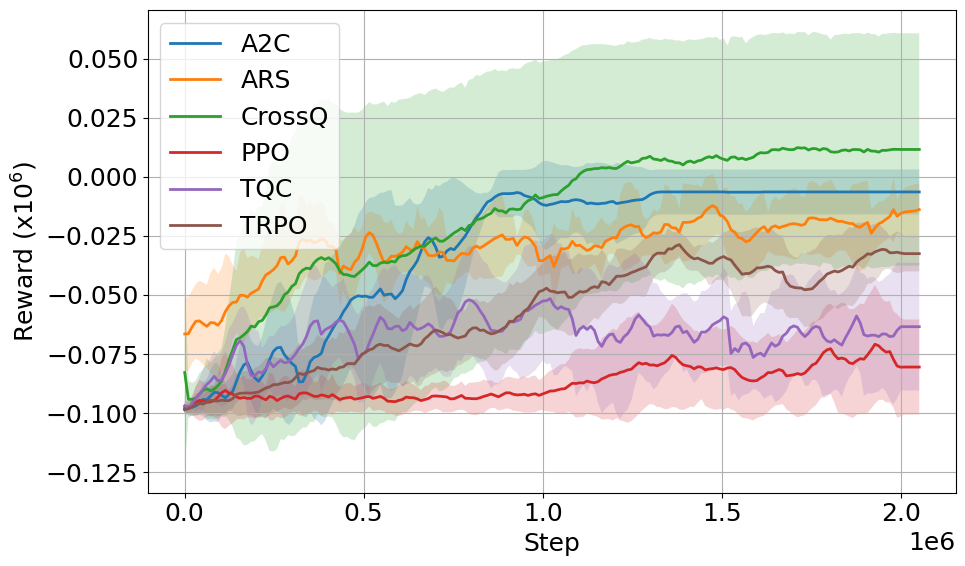

In [6]:
# Define a common x-axis (based on min-max steps across all algorithms)
min_step = df['step'].min()
max_step = df['step'].max()
common_steps = np.linspace(min_step, max_step, 200)

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,6))

# Group by algorithm
for algo, algo_df in df.groupby('algorithm'):
    runs = []

    # For each run (set), interpolate rewards to common steps
    for run_id, run_df in algo_df.groupby('set'):
        x = run_df['step'].values
        y = run_df['reward_scaled'].values
        interp_rewards = np.interp(common_steps, x, y)
        runs.append(interp_rewards)

    runs = np.array(runs)
    mean_rewards = runs.mean(axis=0)
    std_rewards = runs.std(axis=0)

    # Plot with variance shading
    plt.plot(common_steps, mean_rewards, label=algo, linewidth=2)
    plt.fill_between(common_steps, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.2)

plt.xlabel("Step")
plt.ylabel("Reward (x$10^6$)")
# plt.title("RL Algorithms Reward Curves with Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()
os.makedirs("plots", exist_ok=True)
plt.savefig(rf"plots/wheeled_default_{date}.png")
plt.show()

In [7]:
a2c_df = df[df['algorithm']=='A2C']
ppo_df = df[df['algorithm']=='PPO']
trpo_df = df[df['algorithm']=='TRPO']
ars_df = df[df['algorithm']=='ARS']
crossq_df = df[df['algorithm']=='CrossQ']
tqc_df = df[df['algorithm']=='TQC']


a2c_data = {"Setting": "AB", 
            "Algorithm": "A2C", 
            "Mean": a2c_df['reward'].mean(),
            "SD": a2c_df['reward'].std(),
            "Max": a2c_df['reward'].max(),
            "Range": (a2c_df['reward'].max() - a2c_df['reward'].min())}
ppo_data = {"Setting": "AB", 
            "Algorithm": "PPO", 
            "Mean": ppo_df['reward'].mean(),
            "SD": ppo_df['reward'].std(),
            "Max": ppo_df['reward'].max(),
            "Range": (ppo_df['reward'].max() - ppo_df['reward'].min())}
trpo_data = {"Setting": "AB", 
            "Algorithm": "TRPO", 
            "Mean": trpo_df['reward'].mean(),
            "SD": trpo_df['reward'].std(),
            "Max": trpo_df['reward'].max(),
            "Range": (trpo_df['reward'].max() - trpo_df['reward'].min())}
ars_data = {"Setting": "AB", 
            "Algorithm": "ARS", 
            "Mean": ars_df['reward'].mean(),
            "SD": ars_df['reward'].std(),
            "Max": ars_df['reward'].max(),
            "Range": (ars_df['reward'].max() - ars_df['reward'].min())}
crossq_data = {"Setting": "AB", 
            "Algorithm": "CrossQ", 
            "Mean": crossq_df['reward'].mean(),
            "SD": crossq_df['reward'].std(),
            "Max": crossq_df['reward'].max(),
            "Range": (crossq_df['reward'].max() - crossq_df['reward'].min())}
tqc_data = {"Setting": "AB", 
            "Algorithm": "TQC", 
            "Mean": tqc_df['reward'].mean(),
            "SD": tqc_df['reward'].std(),
            "Max": tqc_df['reward'].max(),
            "Range": (tqc_df['reward'].max() - tqc_df['reward'].min())}


set_tab_df = pd.DataFrame([a2c_data, ppo_data, trpo_data, ars_data, crossq_data, tqc_data])
set_tab_df

,Setting,Algorithm,Mean,SD,Max,Range
0,AB,A2C,-29635.164471,36420.969308,18824.000000,120197.398438
1,AB,PPO,-85557.036510,16197.593923,-24684.570312,77683.156250
2,AB,TRPO,-56951.482613,24483.783238,-14022.000000,86876.421875
3,AB,ARS,-22677.785482,24378.949210,28997.318359,123789.037109
4,AB,CrossQ,52168.808599,97897.574659,139898.375000,240523.375000
5,AB,TQC,-76074.695435,22630.012148,5503.511230,107907.214355


In [8]:
set_tab_df_sc = set_tab_df.select_dtypes(include='number') / 1000000
set_tab_df_sc.insert(0, 'Setting', set_tab_df['Setting'])
set_tab_df_sc.insert(1, 'Algorithm', set_tab_df['Algorithm'])
set_tab_df_sc

,Setting,Algorithm,Mean,SD,Max,Range
0,AB,A2C,-0.029635,0.036421,0.018824,0.120197
1,AB,PPO,-0.085557,0.016198,-0.024685,0.077683
2,AB,TRPO,-0.056951,0.024484,-0.014022,0.086876
3,AB,ARS,-0.022678,0.024379,0.028997,0.123789
4,AB,CrossQ,0.052169,0.097898,0.139898,0.240523
5,AB,TQC,-0.076075,0.022630,0.005504,0.107907


In [9]:
set_tab_df_sc.to_csv(rf"results/wheeled_default_results_{date}.csv")